<a href="https://colab.research.google.com/github/dinanrzki/Junior-Data-Analyst-Project/blob/main/Data_Analyst_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv('/content/Student_Performance.csv')

df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [ ]:
print('1. Statistik Deskriptif (Mean, Median, Std Dev, dll.):')
display(df.describe())

1. Statistik Deskriptif (Mean, Median, Std Dev, dll.):


,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [ ]:
print("=== LAPORAN DATA CLEANING ===\n")

print("1. CEK MISSING VALUES:")
print(df.isnull().sum())

print("\n2. CEK DUPLIKAT SEBELUM CLEANING:")
print(f"Jumlah duplikat: {df.duplicated().sum()}")

df = df.drop_duplicates()
print("\n3. SETELAH HAPUS DUPLIKAT:")
print(f"Jumlah data sekarang: {len(df)}")

print("\n4. STANDARISASI EXTRACURRICULAR ACTIVITIES:")
print(f"Sebelum: {df['Extracurricular Activities'].unique()}")
df['Extracurricular Activities'] = df['Extracurricular Activities'].str.strip().str.capitalize()
print(f"Sesudah: {df['Extracurricular Activities'].unique()}")

Q1 = df['Sleep Hours'].quantile(0.25)
Q3 = df['Sleep Hours'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['Sleep Hours'] < Q1 - 1.5*IQR) | (df['Sleep Hours'] > Q3 + 1.5*IQR)]
print(f"\n5. OUTLIER SLEEP HOURS:")
print(f"Jumlah outlier: {len(outliers)}")

df.to_csv('Student_Performance_clean.csv', index=False)
print("\n6. DATA BERSIH TERSIMPAN: Student_Performance_clean.csv")

print("\n=== DATA CLEANING SELESAI ===")

=== LAPORAN DATA CLEANING ===

1. CEK MISSING VALUES:
Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

2. CEK DUPLIKAT SEBELUM CLEANING:
Jumlah duplikat: 127

3. SETELAH HAPUS DUPLIKAT:
Jumlah data sekarang: 9873

4. STANDARISASI EXTRACURRICULAR ACTIVITIES:
Sebelum: ['Yes' 'No']
Sesudah: ['Yes' 'No']

5. OUTLIER SLEEP HOURS:
Jumlah outlier: 0

6. DATA BERSIH TERSIMPAN: Student_Performance_clean.csv

=== DATA CLEANING SELESAI ===


In [ ]:
df = pd.read_csv('/content/Student_Performance_clean.csv')

df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')


2. Distribusi Data untuk Kolom Numerik:


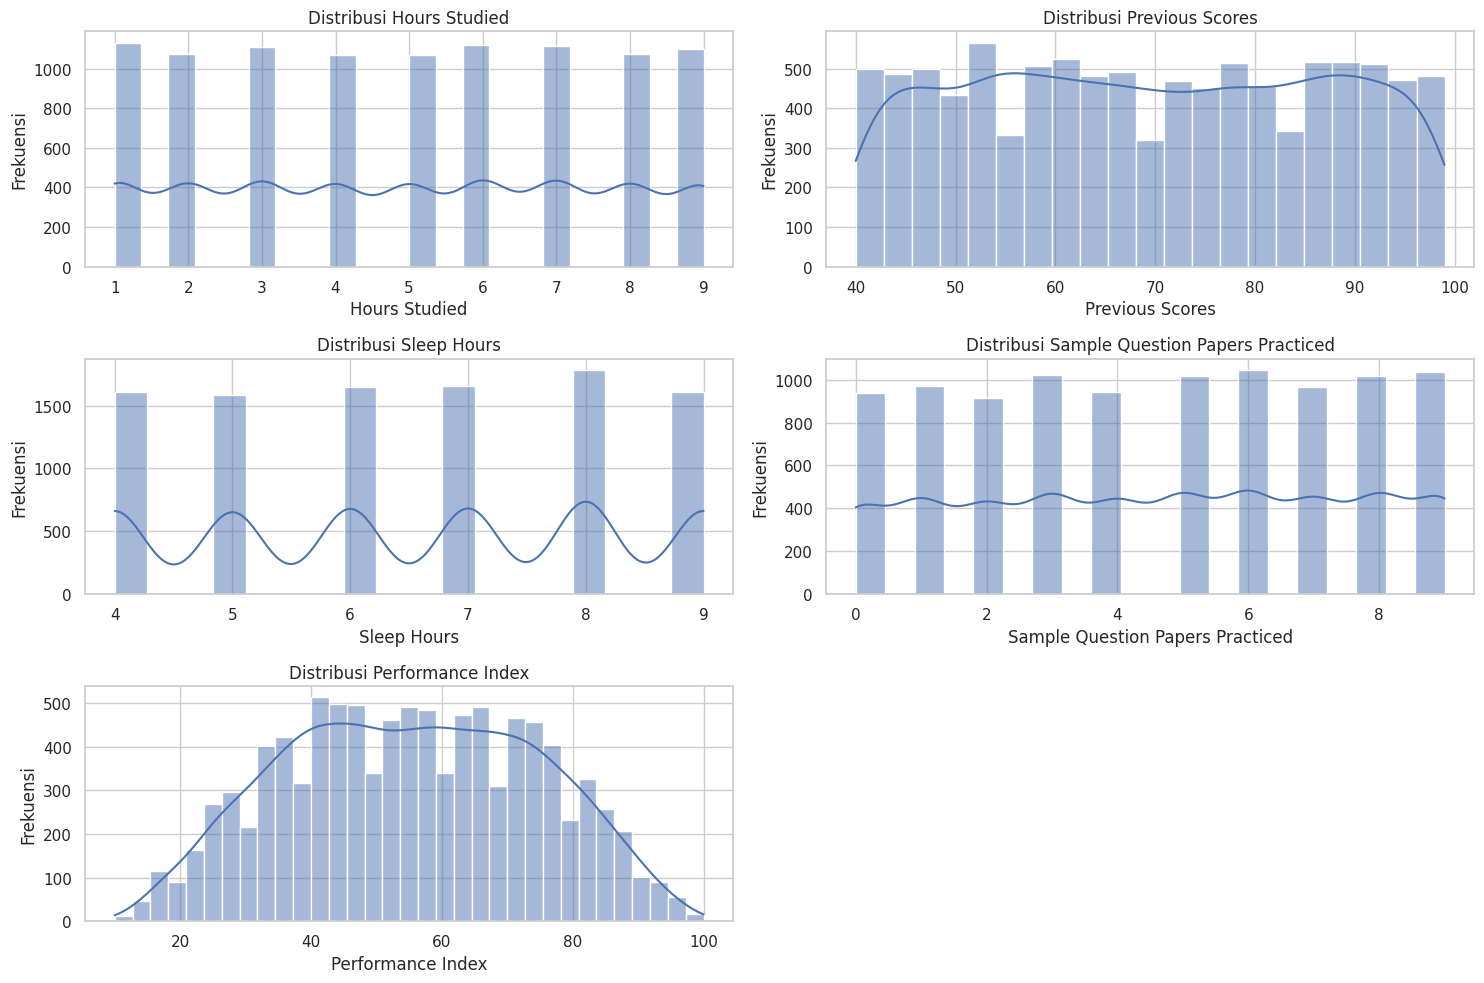

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print('\n2. Distribusi Data untuk Kolom Numerik:')

numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 2, i + 1) # Adjust subplot grid as needed
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribusi {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

In [ ]:
cols = [
    'Hours Studied',
    'Previous Scores',
    'Sleep Hours',
    'Sample Question Papers Practiced',
    'Performance Index'
]

print(df[cols].mean())
print(df[cols].median())
print(df[cols].std())

Hours Studied                        4.992100
Previous Scores                     69.441102
Sleep Hours                          6.531652
Sample Question Papers Practiced     4.583004
Performance Index                   55.216651
dtype: float64
Hours Studied                        5.0
Previous Scores                     69.0
Sleep Hours                          7.0
Sample Question Papers Practiced     5.0
Performance Index                   55.0
dtype: float64
Hours Studied                        2.589081
Previous Scores                     17.325601
Sleep Hours                          1.697683
Sample Question Papers Practiced     2.867202
Performance Index                   19.208570
dtype: float64


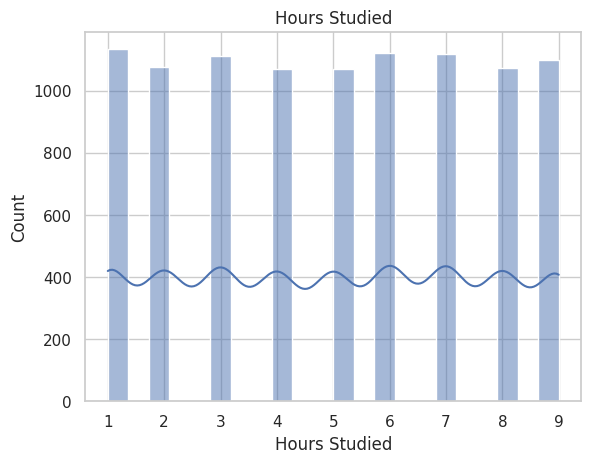

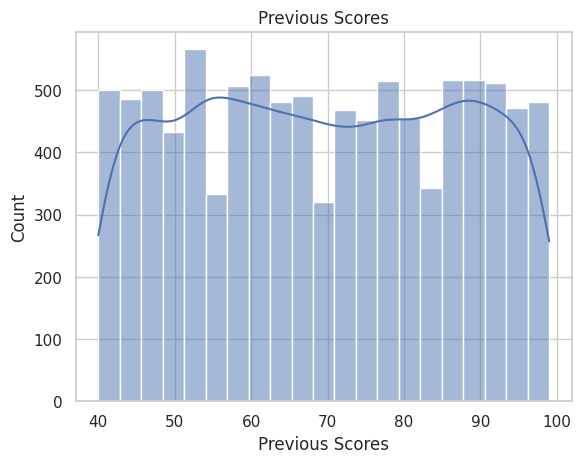

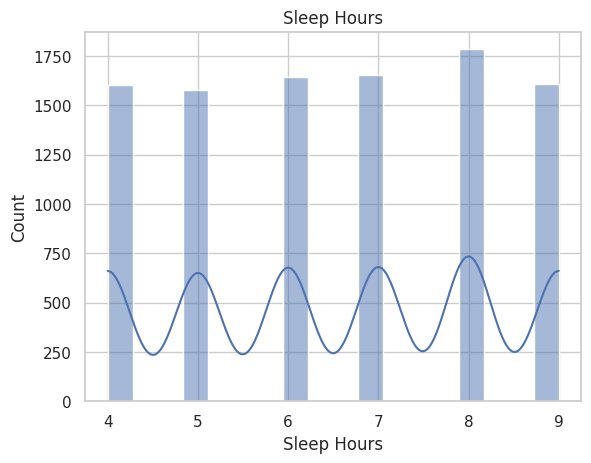

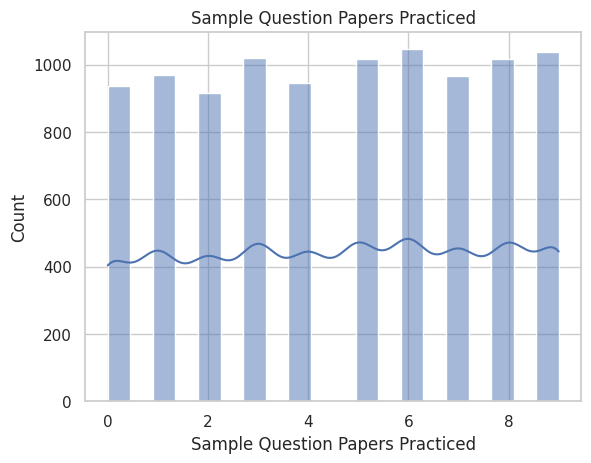

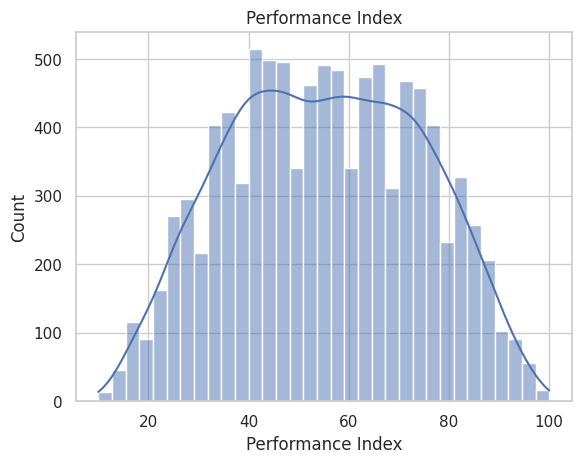

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()


Hubungan Jam Belajar dengan Performance


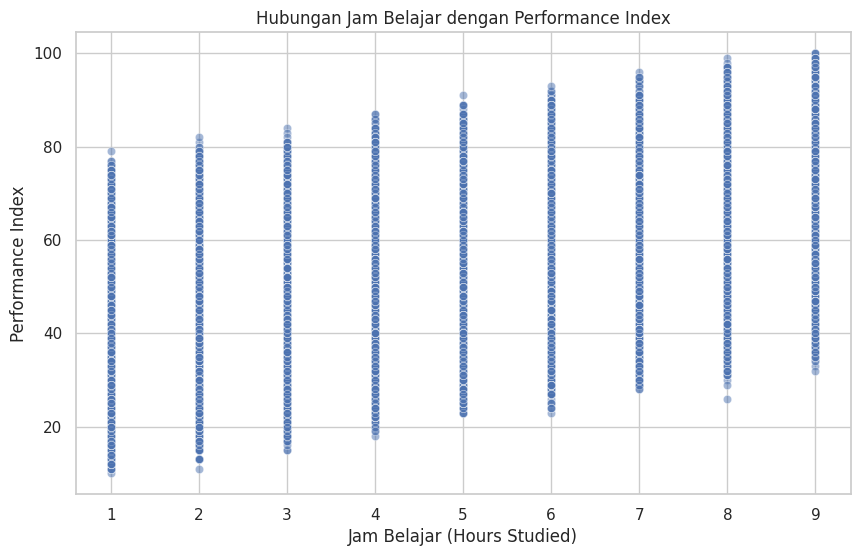

In [ ]:
# Scatter Plot
print("\nHubungan Jam Belajar dengan Performance")

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Hours Studied', y='Performance Index', data=df, alpha=0.5)

plt.title('Hubungan Jam Belajar dengan Performance Index')
plt.xlabel('Jam Belajar (Hours Studied)')
plt.ylabel('Performance Index')

plt.show()

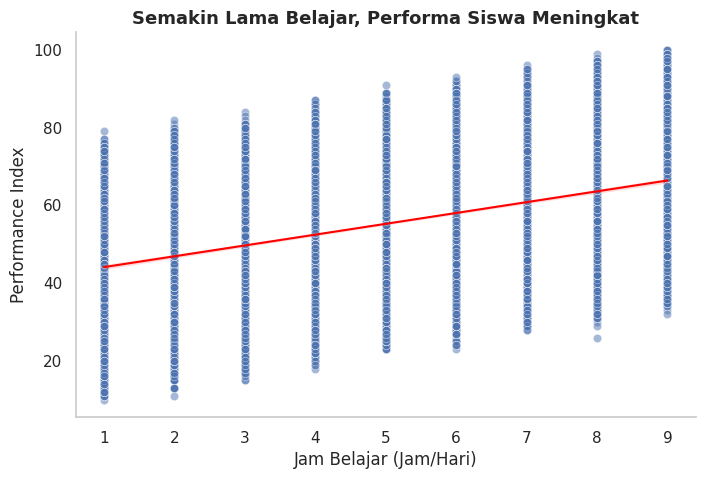

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Hours Studied',
    y='Performance Index',
    data=df,
    alpha=0.5,
    color='#4C72B0'
)

# garis tren tipis (biar insight makin keliatan)
sns.regplot(
    x='Hours Studied',
    y='Performance Index',
    data=df,
    scatter=False,
    color='red',
    line_kws={'linewidth':1.5}
)

plt.title("Semakin Lama Belajar, Performa Siswa Meningkat", fontsize=13, weight='bold')
plt.xlabel("Jam Belajar (Jam/Hari)")
plt.ylabel("Performance Index")

sns.despine()
plt.grid(False)

plt.show()

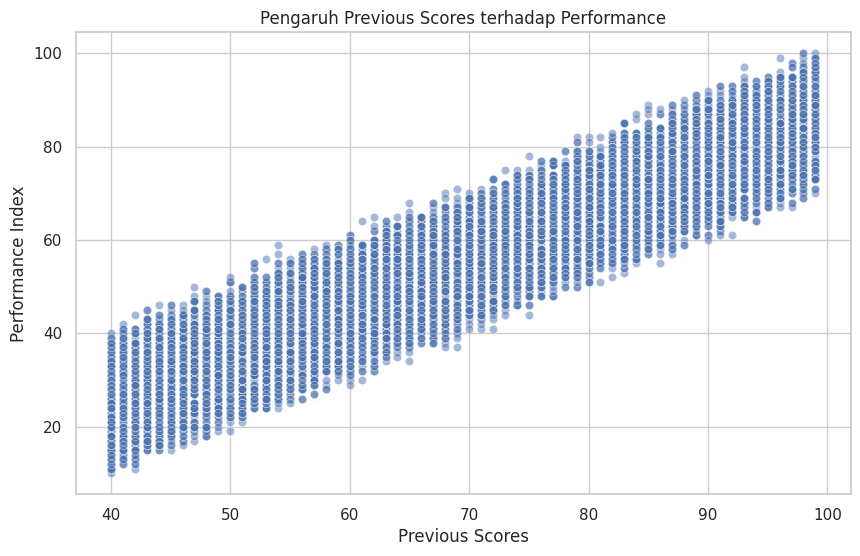

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Previous Scores', y='Performance Index', data=df, alpha=0.5)

plt.title('Pengaruh Previous Scores terhadap Performance')
plt.xlabel('Previous Scores')
plt.ylabel('Performance Index')

plt.show()

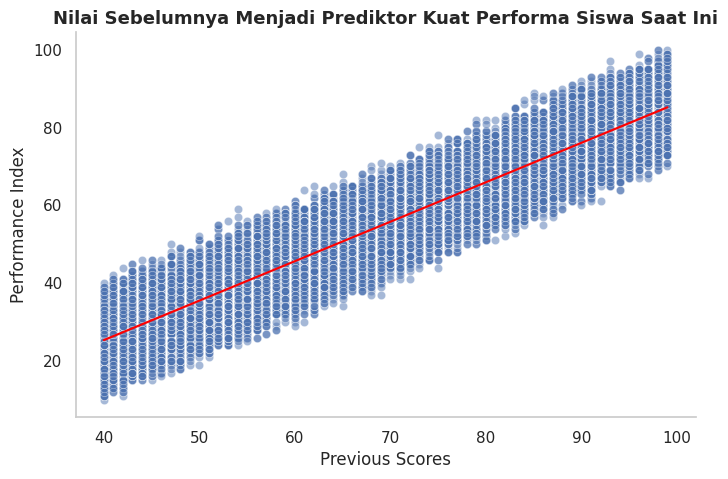

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Previous Scores',
    y='Performance Index',
    data=df,
    alpha=0.5,
    color='#4C72B0'
)

# garis tren (highlight pola kuat)
sns.regplot(
    x='Previous Scores',
    y='Performance Index',
    data=df,
    scatter=False,
    color='red',
    line_kws={'linewidth':1.5}
)

plt.title("Nilai Sebelumnya Menjadi Prediktor Kuat Performa Siswa Saat Ini",
          fontsize=13, weight='bold')

plt.xlabel("Previous Scores")
plt.ylabel("Performance Index")

sns.despine()
plt.grid(False)

plt.show()

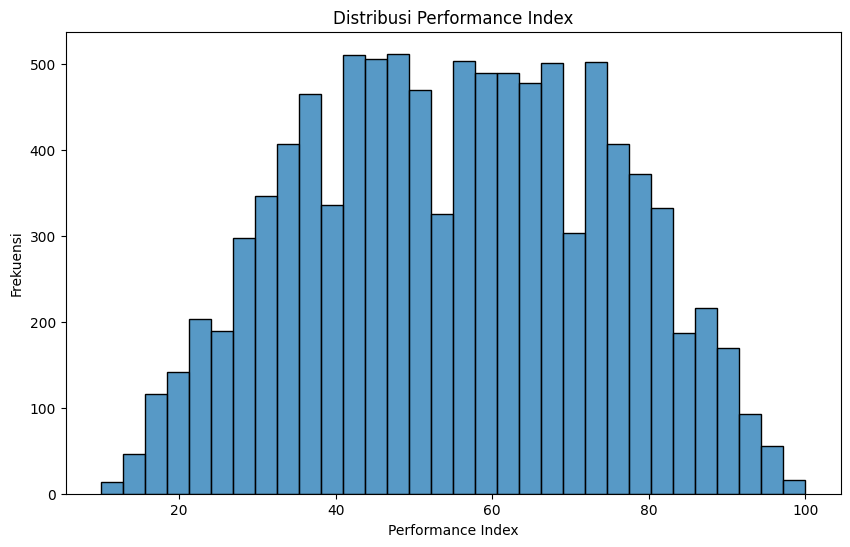

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data (pastikan path lo benar)
df = pd.read_csv('/content/Student_Performance 2.csv')

# BEFORE Histogram
plt.figure(figsize=(10,6))

sns.histplot(df['Performance Index'])

plt.title('Distribusi Performance Index')
plt.xlabel('Performance Index')
plt.ylabel('Frekuensi')

plt.show()